In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

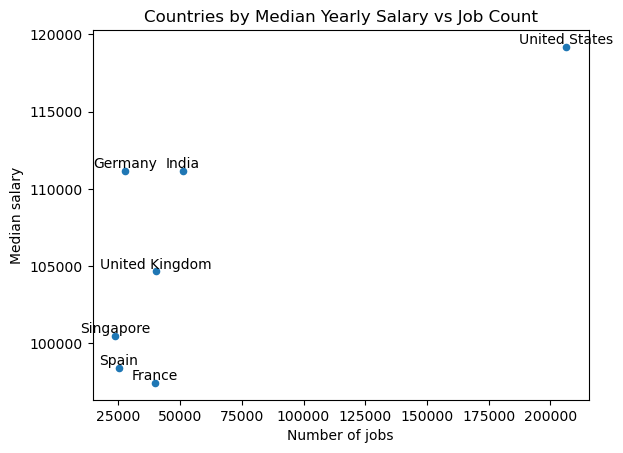

In [ ]:
df_by_country = df.groupby('job_country').agg(
    number_of_jobs = ('job_title_short', 'count'),
    median_salary = ('salary_year_avg', 'median')   
    )

df_sorted = df_by_country.sort_values(by= 'number_of_jobs',ascending=False).head(7)

df_sorted.plot(kind = 'scatter',x= 'number_of_jobs',y= 'median_salary')

for i, country in enumerate(df_sorted.index):
    plt.text(
        df_sorted['number_of_jobs'].iloc[i],
        df_sorted['median_salary'].iloc[i],
        country,
        ha= 'center',
        va='bottom'
        )

plt.title('Top 7 countries by Median Salary vs Job Count')
plt.ylabel('Median salary')
plt.xlabel('Number of jobs')
plt.show()